In [ ]:
import numpy as np
import pandas as pd
import os
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
import matplotlib.pyplot as plt
from skimage.measure import label, regionprops

import cv2


In [30]:
X = pd.read_csv("../X.csv").values
y = pd.read_csv("../y.csv").values.ravel()


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

X_train = X_train[:, :-1]
X_test_sem_src = X_test[:, :-1]


In [ ]:
clsf = {
    "Random Forest": Pipeline([
        ("sc", StandardScaler()),
        ("clf", RandomForestClassifier(n_estimators=100, random_state=42))
    ]),
    "SVM": Pipeline([
        ("sc", StandardScaler()),
        ("clf", SVC(kernel='rbf', C=1.0, random_state=42))
    ])
}

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

X_features = X[:, :-1].astype(float)

linhas = []

for nome, clf in clsf.items():
    acc = cross_val_score(clf, X_features, y, cv=cv, scoring="accuracy")
    f1  = cross_val_score(clf, X_features, y, cv=cv, scoring="f1_macro")

    linhas.append({
        "clf": nome,
        "acuracia_media":  acc.mean(),
        "acuracia_desvio": acc.std(),
        "f1_macro_media":  f1.mean(),
        "f1_macro_desvio": f1.std()
    })

resultado_classificadores = pd.DataFrame(linhas).sort_values(
    "acuracia_media", ascending=False
)

resultado_classificadores.round(3)


In [ ]:
modelos = {
    "Random Forest": Pipeline([
        ("sc", StandardScaler()),
        ("clf", RandomForestClassifier(n_estimators=100, random_state=42))
    ]),
    "SVM": Pipeline([
        ("sc", StandardScaler()),
        ("clf", SVC(kernel='rbf', C=1.0, random_state=42))
    ])
}

predicoes = {}

for nome, modelo in modelos.items():
    print(f"Treinando o modelo: {nome}")
    
    modelo.fit(X_train, y_train)
    
    predicoes[nome] = modelo.predict(X_test_sem_src)
    print(f"{nome} finalizado")


Treinando o modelo: Random Forest
Random Forest finalizado
Treinando o modelo: SVM
SVM finalizado


Classificação de Random Forest
              precision    recall  f1-score   support

       fresh       0.99      0.99      0.99       294
      rotten       0.99      0.99      0.99       319

    accuracy                           0.99       613
   macro avg       0.99      0.99      0.99       613
weighted avg       0.99      0.99      0.99       613

--------------------------------------------------
Classificação de SVM
              precision    recall  f1-score   support

       fresh       0.96      0.96      0.96       294
      rotten       0.97      0.96      0.96       319

    accuracy                           0.96       613
   macro avg       0.96      0.96      0.96       613
weighted avg       0.96      0.96      0.96       613

--------------------------------------------------


Classificação de Random Forest
              precision    recall  f1-score   support

       fresh       0.99      0.99      0.99       294
      rotten       0.99      0.99      0.99       319

    accuracy                           0.99       613
   macro avg       0.99      0.99      0.99       613
weighted avg       0.99      0.99      0.99       613

--------------------------------------------------
Classificação de SVM
              precision    recall  f1-score   support

       fresh       0.96      0.96      0.96       294
      rotten       0.97      0.96      0.96       319

    accuracy                           0.96       613
   macro avg       0.96      0.96      0.96       613
weighted avg       0.96      0.96      0.96       613

--------------------------------------------------


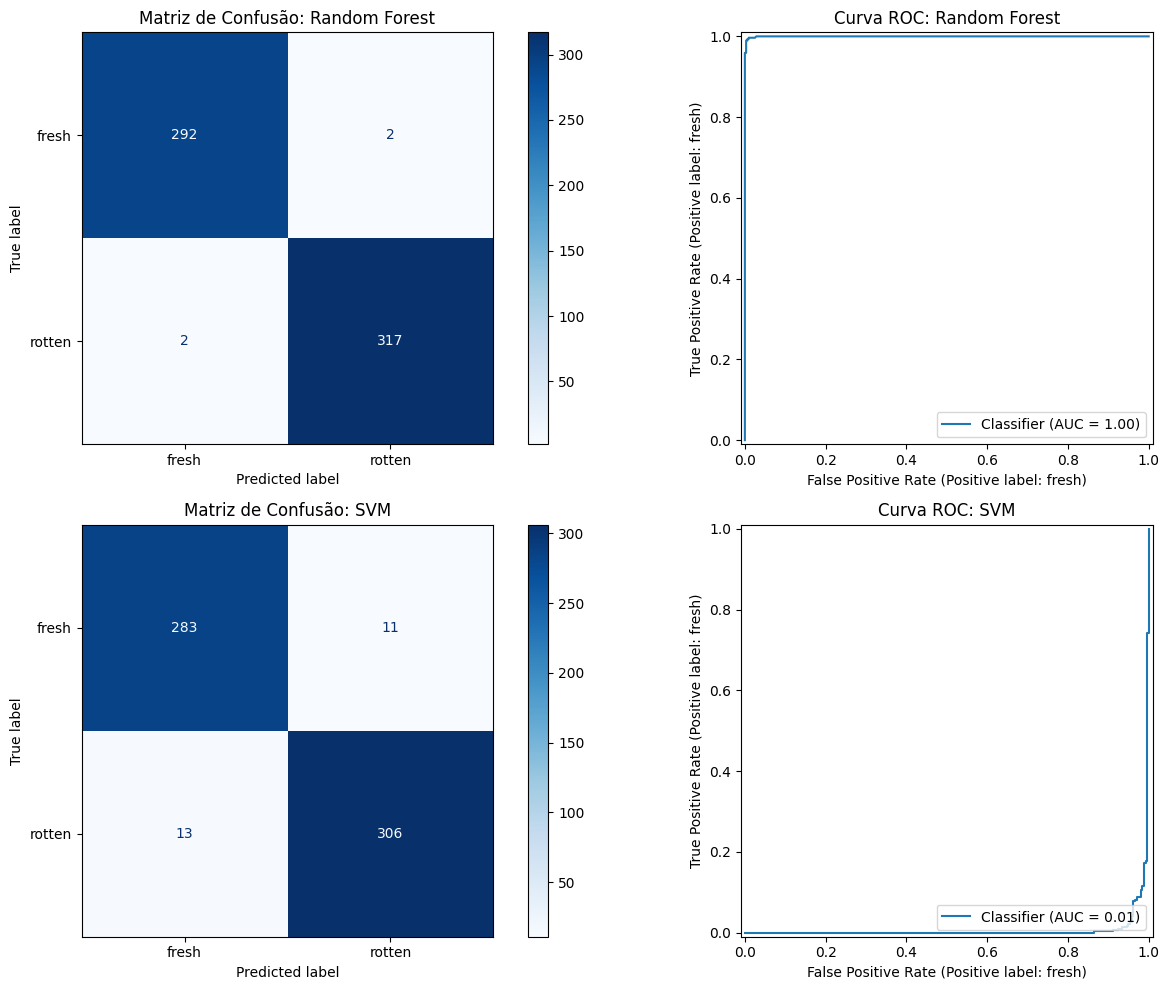

In [32]:
classe_positiva = "fresh"

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, (nome, preds) in enumerate(predicoes.items()):
    print(f"Classificação de {nome}")
    print(classification_report(y_test, preds))
    print("-" * 50)

    # Matriz de Confusão
    cm = confusion_matrix(y_test, preds, labels=["fresh", "rotten"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["fresh", "rotten"])
    disp.plot(ax=axes[idx, 0], cmap=plt.cm.Blues, values_format='d')
    axes[idx, 0].set_title(f"Matriz de Confusão: {nome}")

    # Curva ROC
    modelo = modelos[nome]
    if hasattr(modelo, "predict_proba"):
        Y_prob = modelo.predict_proba(X_test_sem_src)[:, list(modelo.classes_).index(classe_positiva)]
    else:
        Y_prob = modelo.decision_function(X_test_sem_src)

    RocCurveDisplay.from_predictions(
        y_test,
        Y_prob,
        pos_label=classe_positiva,
        ax=axes[idx, 1]
    )
    axes[idx, 1].set_title(f"Curva ROC: {nome}")

plt.tight_layout()
plt.savefig("../outputs/matrizes-de-confusao/matrizes.jpg")
plt.show()


In [7]:
def segmentar_laranja(img_rgb):

    bgr = cv2.cvtColor(img_rgb,cv2.COLOR_RGB2BGR)
    hsv = cv2.cvtColor(bgr,cv2.COLOR_BGR2HSV)

    lower = np.array([5, 50, 50])
    upper = np.array([35, 255, 255])

    mask = cv2.inRange(hsv, lower, upper)

    se = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(5, 5))

    mask = cv2.morphologyEx(mask,cv2.MORPH_OPEN,se,iterations=2)
    mask = cv2.morphologyEx(mask,cv2.MORPH_CLOSE,se,iterations=3)

    lbl = label(mask > 0)
    props = regionprops(lbl)

    if len(props) == 0:
        return None

    maior = max(props,key=lambda r: r.area).label

    mask_final = (lbl == maior).astype(np.uint8) * 255

    return mask_final

def desenhar_contorno(bgr, mask):
    imagem_contorno = bgr.copy()

    contornos, _ = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    cv2.drawContours(
        imagem_contorno,
        contornos,
        -1,
        (0, 255, 0),
        2
    )

    return imagem_contorno


Modelo: Random Forest
Total de falsos negativos encontrados: 2


,arquivo,classe_real,classe_predita,prob_fresh,prob_rotten
356,../dataset/freshoranges\saltandpepper_Screen S...,fresh,rotten,0.34,0.66
380,../dataset/freshoranges\translation_Screen Sho...,fresh,rotten,0.45,0.55


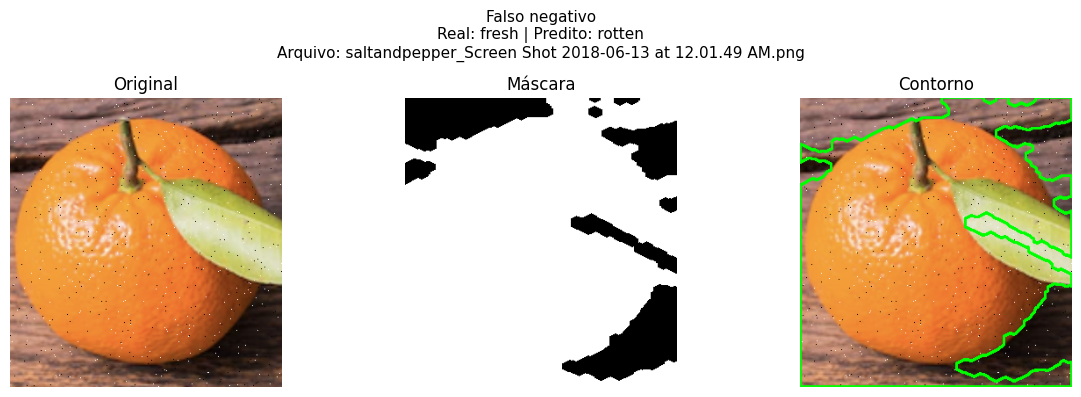

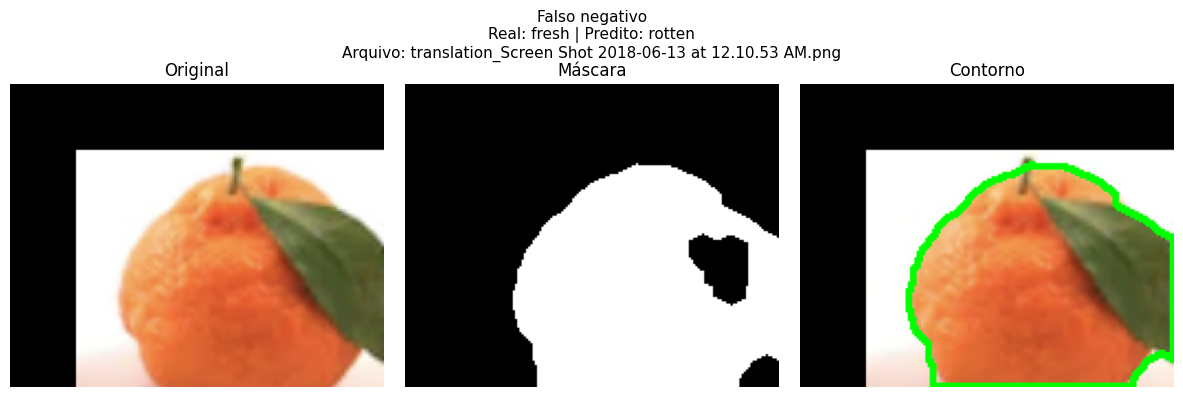


Modelo: SVM
Total de falsos negativos encontrados: 11


,arquivo,classe_real,classe_predita
8,../dataset/freshoranges\translation_Screen Sho...,fresh,rotten
228,../dataset/freshoranges\saltandpepper_Screen S...,fresh,rotten
235,../dataset/freshoranges\saltandpepper_Screen S...,fresh,rotten
300,../dataset/freshoranges\saltandpepper_Screen S...,fresh,rotten
356,../dataset/freshoranges\saltandpepper_Screen S...,fresh,rotten
380,../dataset/freshoranges\translation_Screen Sho...,fresh,rotten
410,../dataset/freshoranges\rotated_by_75_Screen S...,fresh,rotten
429,../dataset/freshoranges\rotated_by_15_Screen S...,fresh,rotten
469,../dataset/freshoranges\vertical_flip_Screen S...,fresh,rotten
508,../dataset/freshoranges\vertical_flip_Screen S...,fresh,rotten


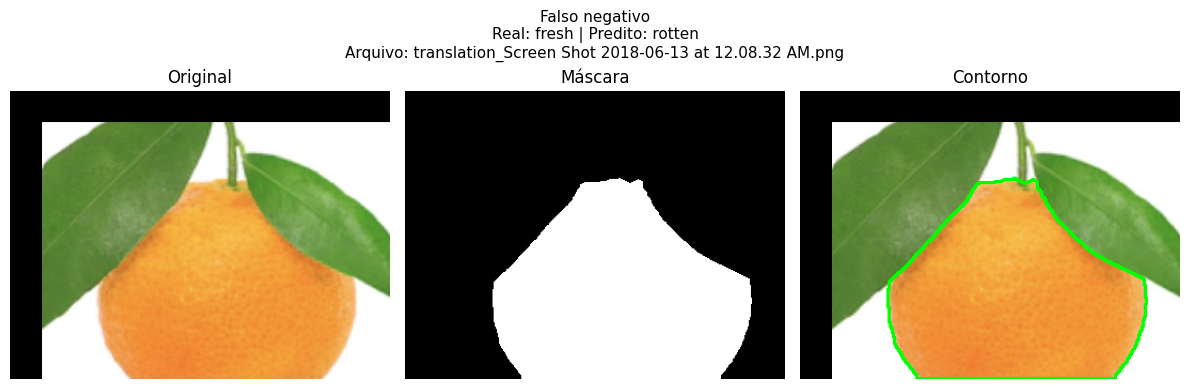

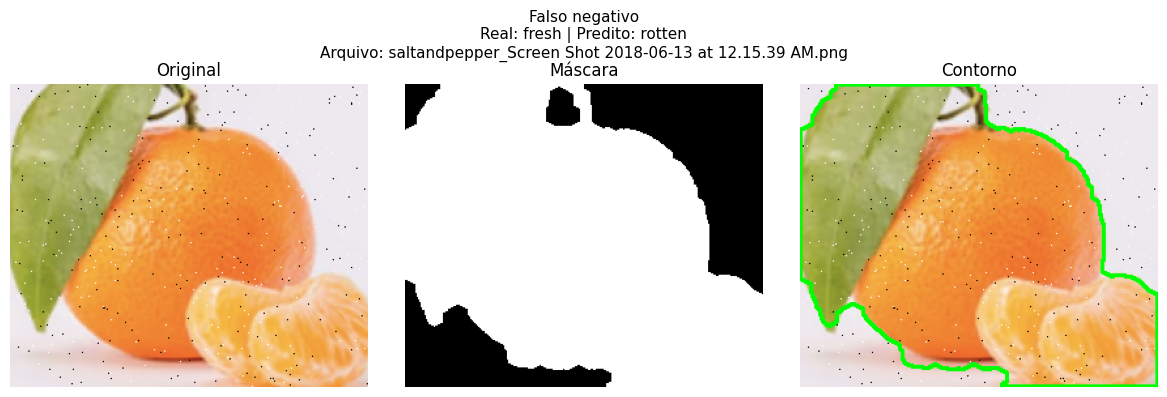

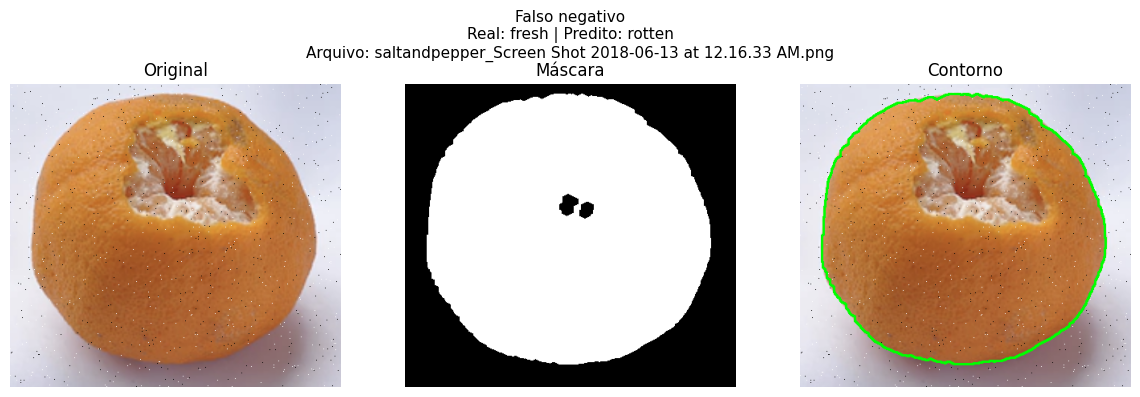

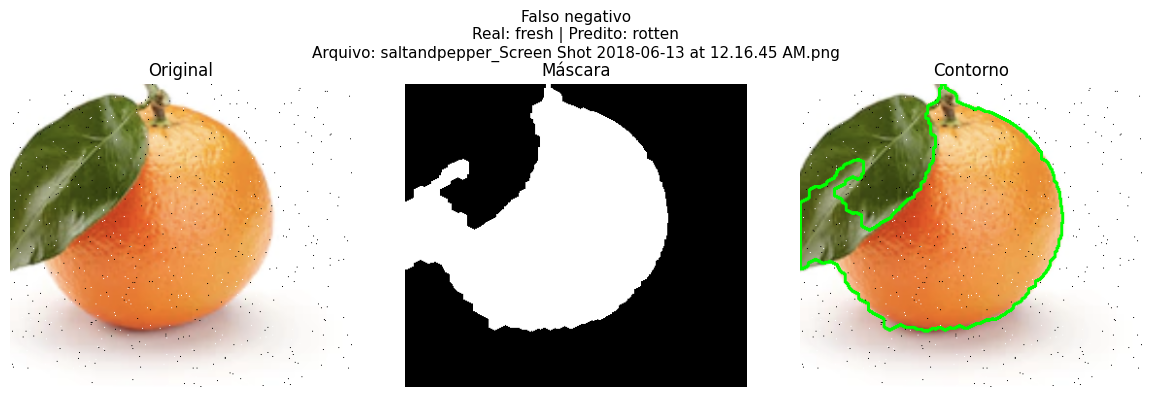

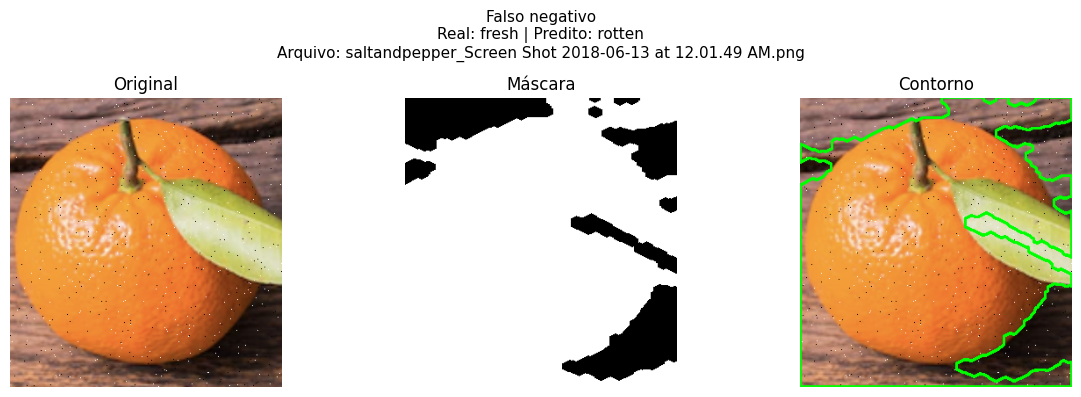

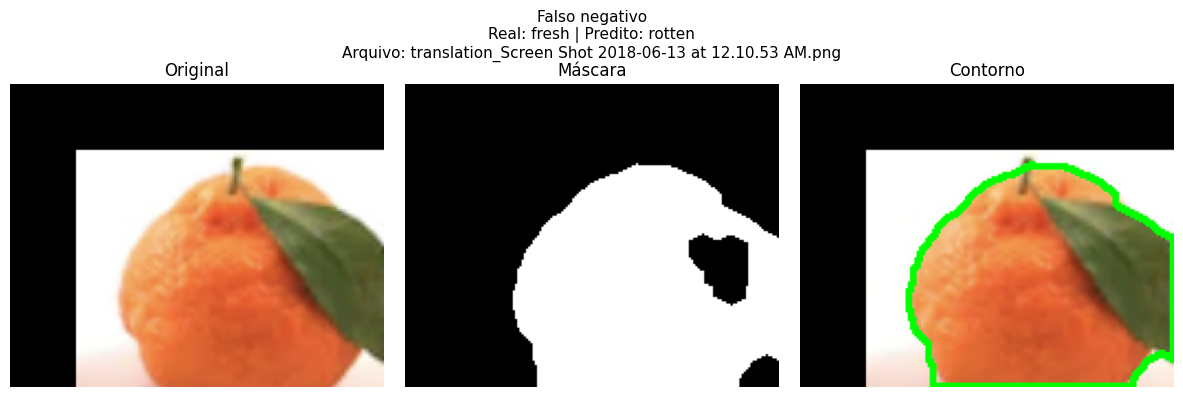

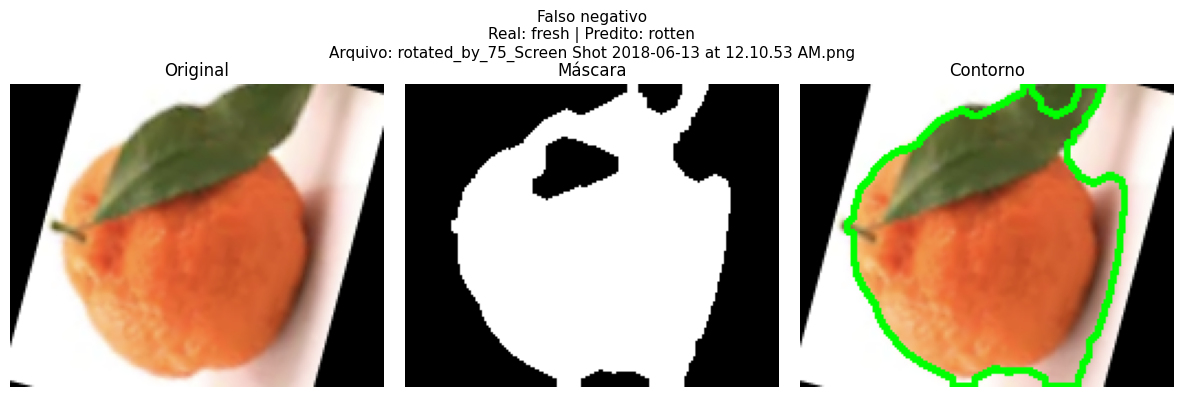

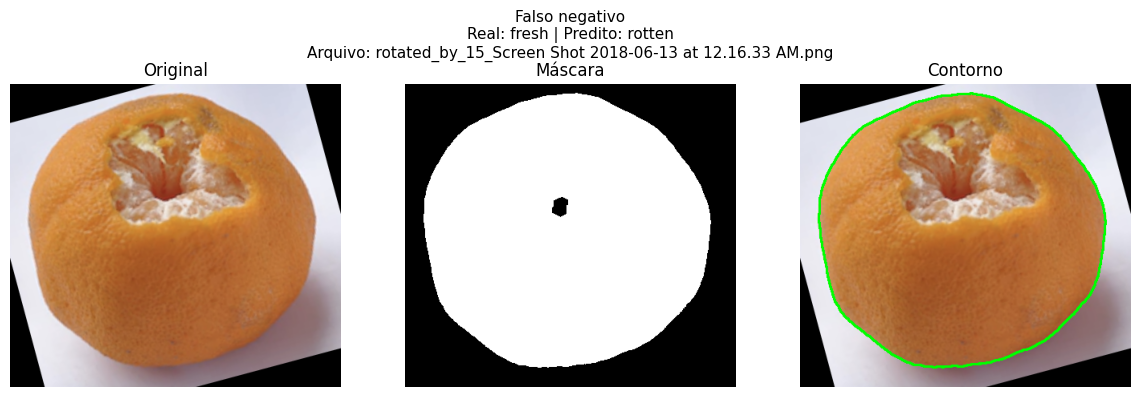

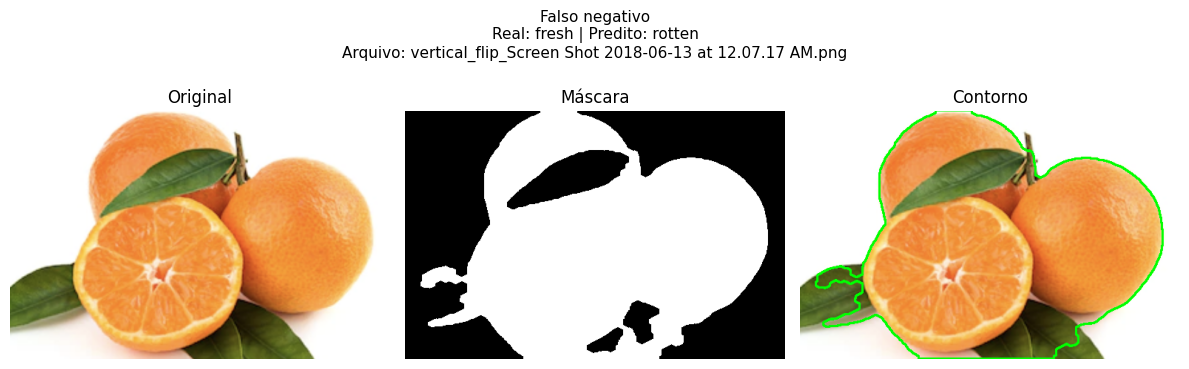

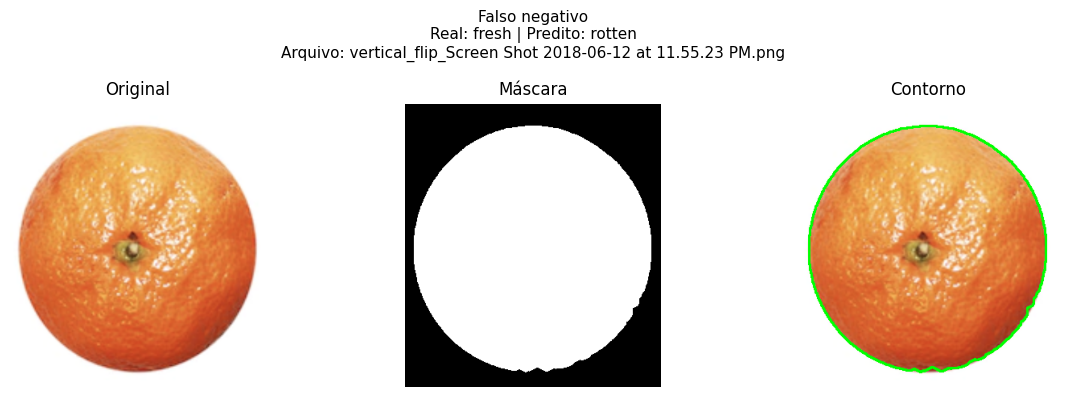

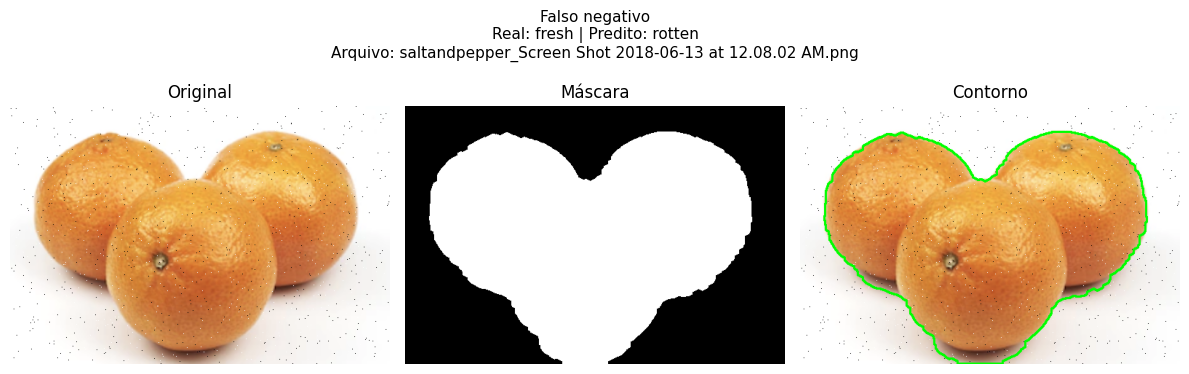

In [10]:
# Identificar imagens classificadas como falso negativo
classificacao_positiva = "fresh"

for nome, preds in predicoes.items():
    resultado_teste = pd.DataFrame({
        "arquivo": X_test[:, -1],
        "classe_real": y_test,
        "classe_predita": preds
    })

    # Adiciona probabilidades quando o modelo oferecer suporte
    modelo = modelos[nome]
    if hasattr(modelo, "predict_proba"):
        try:
            probs = modelo.predict_proba(X_test_sem_src)
            for i, nome_classe in enumerate(modelo.classes_):
                resultado_teste[f"prob_{nome_classe}"] = probs[:, i]
        except Exception:
            pass

    falsos_negativos = resultado_teste[
        (resultado_teste["classe_real"] == classificacao_positiva) &
        (resultado_teste["classe_predita"] != classificacao_positiva)
    ].copy()

    print(f"\nModelo: {nome}")
    print(f"Total de falsos negativos encontrados: {len(falsos_negativos)}")

    colunas_prob = [c for c in resultado_teste.columns if c.startswith("prob_")]
    colunas_exibir = ["arquivo", "classe_real", "classe_predita"] + colunas_prob
    display(falsos_negativos[colunas_exibir])

    pasta_saida = f"../outputs/imagens-de-erros/{nome.replace(' ', '-')}"
    os.makedirs(pasta_saida, exist_ok=True)

    # Exibe e salva visualmente cada falso negativo encontrado
    for _, row in falsos_negativos.iterrows():
        caminho = row["arquivo"]

        bgr = cv2.imread(caminho)
        if bgr is None:
            print(f"Não foi possível abrir a imagem: {caminho}")
            continue

        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        mask = segmentar_laranja(rgb)
        if mask is None:
            print(f"Não foi possível segmentar a laranja em: {caminho}")
            continue

        contorno = desenhar_contorno(bgr, mask)

        fig, ax = plt.subplots(1, 3, figsize=(12, 4))

        ax[0].imshow(rgb)
        ax[0].set_title("Original")
        ax[0].axis("off")

        ax[1].imshow(mask, cmap="gray")
        ax[1].set_title("Máscara")
        ax[1].axis("off")

        ax[2].imshow(cv2.cvtColor(contorno, cv2.COLOR_BGR2RGB))
        ax[2].set_title("Contorno")
        ax[2].axis("off")

        fig.suptitle(
            f"Falso negativo\n"
            f"Real: {row['classe_real']} | Predito: {row['classe_predita']}\n"
            f"Arquivo: {os.path.basename(caminho)}",
            fontsize=11
        )

        plt.tight_layout()

        nome_base = os.path.splitext(os.path.basename(caminho))[0]
        caminho_saida = f"{pasta_saida}/fn-{nome_base}.png"
        fig.savefig(caminho_saida, dpi=150, bbox_inches="tight")

        plt.show()
        plt.close(fig)
